# M4-B1 — Benchmark Mistral Assurances

> Concevoir une IA simple : benchmark 3+ familles de modèles + grille
> de décision. Référence baseline : `mistral-tarif-v1` (R² 0.39).

Auteur·rice : `<prénom>` — Date : `<date>`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append('../src')

RANDOM_STATE = 42
DATA_PATH = Path('../data/bike_sharing.csv')
sns.set_theme(style='whitegrid')

## 1. Reprise baseline mistral-tarif-v1 (~30 min)

Charge le modèle baseline depuis le repo `mistral-tarif-v1`, note ses
métriques rapportées (R² 0.39, MAE 105, RMSE 139), identifie les angles
morts du code 2024 (cf. mini-cours 04 méthodologie benchmark).

In [19]:
# Étape 1 — charger le baseline mistral-tarif-v1.
# Prérequis : cloner le repo baseline EN VOISIN de ton repo M4-B1
# (dans le dossier PARENT, pour que le chemin ../ ci-dessous fonctionne) :
#   git clone https://github.com/Formation-SIMPLON-IA/mistral-tarif-v1.git
import joblib

# suppose le baseline cloné en voisin de ton repo M4-B1
model_v1 = joblib.load("../mistral-tarif-v1/models/mistral_tarif_v1.joblib")
model_v1


LinearRegression()

## 2. EDA orientée saisonnalité (~1h30)

Au moins **4 visualisations Seaborn** : boxplot par saison, courbe par
heure-moyenne, scatter température vs cnt, corrélations.

> *« Quelle saisonnalité je vois ? Comment elle explique la
> sous-performance de la baseline ? »*

In [20]:
df = pd.read_csv(DATA_PATH)
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      17379 non-null  int64  
 1   date                    17379 non-null  object 
 2   season                  17379 non-null  object 
 3   year                    17379 non-null  int64  
 4   month                   17379 non-null  int64  
 5   hour                    17379 non-null  int64  
 6   is_holiday              17379 non-null  int64  
 7   weekday                 17379 non-null  int64  
 8   is_working_day          17379 non-null  int64  
 9   weather                 17379 non-null  int64  
 10  temperature_norm        17379 non-null  float64
 11  temperature_feels_norm  17379 non-null  float64
 12  humidity_norm           17379 non-null  float64
 13  windspeed_norm          17379 non-null  float64
 14  casual_riders           17379 non-null

,id,date,season,year,month,hour,is_holiday,weekday,is_working_day,weather,temperature_norm,temperature_feels_norm,humidity_norm,windspeed_norm,casual_riders,registered_riders,total_rentals
0,1,2011-01-01,winter,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,winter,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,winter,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


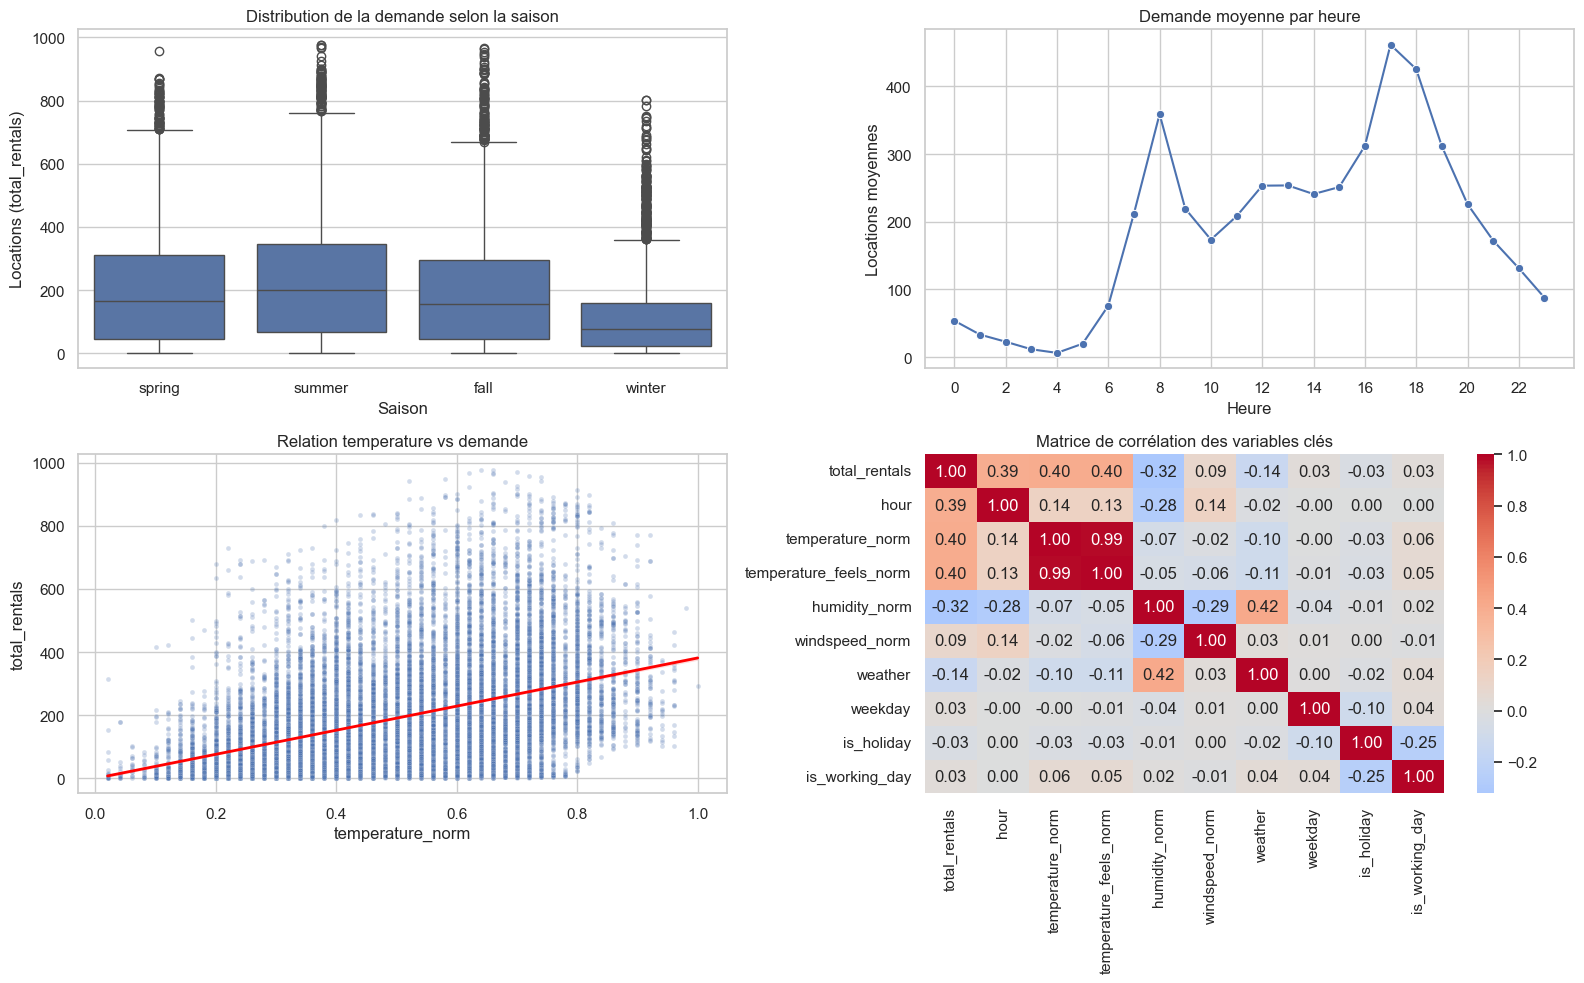

In [21]:
def pick_col(candidates):
    return next((c for c in candidates if c in df.columns), None)

target_col = pick_col(["cnt", "total_rentals"])
season_col = pick_col(["season"])
hour_col = pick_col(["hr", "hour"])
temp_col = pick_col(["temp", "temperature_norm"])
atemp_col = pick_col(["atemp", "temperature_feels_norm"])
hum_col = pick_col(["hum", "humidity_norm"])
wind_col = pick_col(["windspeed", "windspeed_norm"])
weather_col = pick_col(["weathersit", "weather"])
holiday_col = pick_col(["holiday", "is_holiday"])
working_col = pick_col(["workingday", "is_working_day"])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax1, ax2, ax3, ax4 = axes.ravel()

# 1) Boxplot de la cible par saison
if season_col and target_col:
    eda_df = df.copy()
    eda_df["season_label"] = eda_df[season_col].astype(str).str.lower()
    season_order_pref = ["spring", "summer", "fall", "winter", "printemps", "ete", "automne", "hiver"]
    present = eda_df["season_label"].dropna().unique().tolist()
    season_order = [s for s in season_order_pref if s in present] + [s for s in present if s not in season_order_pref]

    sns.boxplot(data=eda_df, x="season_label", y=target_col, order=season_order if season_order else None, ax=ax1)
    ax1.set_title("Distribution de la demande selon la saison")
    ax1.set_xlabel("Saison")
    ax1.set_ylabel(f"Locations ({target_col})")
else:
    ax1.text(0.5, 0.5, "Colonnes manquantes pour le boxplot saison.", ha="center", va="center")
    ax1.set_axis_off()

# 2) Courbe de la demande moyenne par heure
if hour_col and target_col:
    hourly = df.groupby(hour_col, as_index=False)[target_col].mean()
    sns.lineplot(data=hourly, x=hour_col, y=target_col, marker="o", ax=ax2)
    ax2.set_title("Demande moyenne par heure")
    ax2.set_xlabel("Heure")
    ax2.set_ylabel("Locations moyennes")
    if pd.api.types.is_numeric_dtype(df[hour_col]):
        ax2.set_xticks(range(0, 24, 2))
else:
    ax2.text(0.5, 0.5, "Colonnes manquantes pour la courbe horaire.", ha="center", va="center")
    ax2.set_axis_off()

# 3) Scatter température vs demande
if temp_col and target_col:
    sns.scatterplot(data=df, x=temp_col, y=target_col, alpha=0.25, s=12, ax=ax3)
    sns.regplot(data=df, x=temp_col, y=target_col, scatter=False, color="red", line_kws={"linewidth": 2}, ax=ax3)
    ax3.set_title("Relation temperature vs demande")
    ax3.set_xlabel(temp_col)
    ax3.set_ylabel(target_col)
else:
    ax3.text(0.5, 0.5, "Colonnes manquantes pour le scatter temperature.", ha="center", va="center")
    ax3.set_axis_off()

# 4) Heatmap de corrélation (variables numériques clés)
corr_candidates = [target_col, season_col, hour_col, temp_col, atemp_col, hum_col, wind_col, weather_col, "weekday", holiday_col, working_col]
corr_cols = [c for c in corr_candidates if c and pd.api.types.is_numeric_dtype(df[c])]

if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax4)
    ax4.set_title("Matrice de corrélation des variables clés")
else:
    ax4.text(0.5, 0.5, "Pas assez de colonnes numériques pour la heatmap.", ha="center", va="center")
    ax4.set_axis_off()

plt.tight_layout()
plt.show()

### Conclusion de l'EDA

- La demande présente une saisonnalité marquée: printemps-été-automne au-dessus de l'hiver, avec un risque de sous-estimation des périodes hautes par un modèle trop simple.
- Le profil horaire est bimodal (pic vers 8h et surtout 17-18h), ce qui traduit une dynamique pendulaire non linéaire.
- La température est positivement liée à la demande, alors que l'humidité et une météo défavorable la réduisent.
- Les variables température et ressenti sont presque redondantes, donc à surveiller pour éviter une interprétation biaisée.
- Au vu de ces patterns, une famille arbre/ensemble est attendue plus performante qu'une régression linéaire seule.

## 3. Split argumenté + validation croisée (~30 min)

Choisir **`TimeSeriesSplit`** ou **`KFold` stratifié** — justifier.

Mini-cours 02 (split temporel vs stratifié) à consulter.

> 🎓 **Réflexe anti-fuite (la leçon de M2-B1, enfin mise en œuvre).** En M2-B1 tu
> as construit un `Pipeline` sans modèle ni split : la fuite ne pouvait pas se
> produire. Ici tu as **un split ET un modèle** → la règle s'applique : un
> préprocesseur **qui apprend des paramètres** (`StandardScaler`, `SimpleImputer`)
> ne se `fit` **jamais** sur l'ensemble des données. On l'enferme dans le
> `Pipeline` du modèle, et c'est **ce Pipeline** qu'on passe à la validation
> croisée — scikit-learn re-`fit` alors le scaler sur les seuls folds
> d'entraînement. Sinon : fuite → R² **optimiste mensonger**. On le démontre
> juste en dessous.

In [5]:
from sklearn.model_selection import TimeSeriesSplit

# Choix argumenté: TimeSeriesSplit car la demande de vélos dépend du temps
splitter = TimeSeriesSplit(n_splits=5)
splitter

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

### 🔬 Fuite de données — démonstration (à faire une fois)

Avant de lancer la cellule : vérifie que ton `X` **exclut**
`casual_riders` / `registered_riders` (ils somment la cible → fuite de cible,
R² ~1.0). La cellule compare ensuite le R² en CV selon que le `StandardScaler`
est fitté sur **tout** `X` (fuite de prétraitement) ou **dans le `Pipeline`**.

> **À rédiger après exécution** (1-2 phrases, → journal de bord) : quel écart
> observes-tu ? Sur 17k lignes il sera **faible** — explique *dans quel cas* il
> exploserait (peu de données, imputation moyenne/médiane, encodage supervisé).
> C'est pour ça qu'on encapsule le prétraitement **par défaut**, pas seulement
> quand la fuite se voit.

In [6]:
# 🔬 Démonstration fuite vs propre (Ridge) — à exécuter une fois le
# preprocessing complété (FEATURES rempli dans preprocess.py).
# Cellule pré-écrite : tu n'as pas à la coder, juste à la faire tourner.
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from preprocess import load_dataset

try:
    X_demo, y_demo = load_dataset(DATA_PATH)   # SANS casual_riders / registered_riders (fuite de cible)
    splitter_demo = TimeSeriesSplit(n_splits=5)

    # (1) FUITE : le scaler est fitté sur TOUT X, avant la validation croisée
    X_leak = StandardScaler().fit_transform(X_demo)
    r2_leak = cross_val_score(Ridge(alpha=1.0), X_leak, y_demo, cv=splitter_demo, scoring="r2").mean()

    # (2) PROPRE : le scaler vit DANS le pipeline -> re-fitté sur chaque fold d'entraînement
    r2_clean = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=1.0)), X_demo, y_demo, cv=splitter_demo, scoring="r2"
    ).mean()

    display(pd.DataFrame(
        {"R² moyen (CV)": [round(r2_leak, 4), round(r2_clean, 4)]},
        index=["fuite (fit sur tout X)", "propre (fit dans le pipeline)"],
    ))
except Exception as e:
    print(f"⏳ Démo à relancer une fois preprocess.load_dataset opérationnel (FEATURES rempli). Détail : {e}")


,R² moyen (CV)
fuite (fit sur tout X),0.2278
propre (fit dans le pipeline),0.2278


### Journal de bord — interprétation de la démo fuite

> L'écart observé entre le R² "fuite" et le R² "propre" est ici très faible (quasi nul), ce qui est attendu sur un dataset assez volumineux (~17k lignes) avec un prétraitement simple.

Ce même écart peut devenir important quand il y a peu de données, une imputation moyenne/médiane (statistiques très sensibles au leakage) ou un encodage supervisé (target encoding). C'est pourquoi on encapsule le prétraitement dans un `Pipeline` par défaut, même quand la fuite est peu visible dans les métriques.

## 4. Benchmark — 3 familles minimum (~2h)

**Famille A** — Linéaire (Ridge ou variante)  
**Famille B** — Arbre / RandomForest  
**Famille C** — Gradient Boosting (HistGradientBoostingRegressor)

Pour chaque modèle :
- Mêmes folds, mêmes métriques
- MAE, RMSE, R²
- Temps train, latence inférence
- Persistance `.joblib` dans `models/`

> ⚠️ **Règle d'or** : réutilise **exactement le même splitter** que la section 3 (Split). Un splitter différent d'un modèle à l'autre = comparaison invalide.


In [ ]:
from pathlib import Path
import json
from datetime import datetime, timezone
import joblib

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit

from preprocess import load_dataset, FEATURES, TARGET
from train_models import run_benchmark


X, y = load_dataset(DATA_PATH)

splitter_benchmark = splitter if 'splitter' in globals() else TimeSeriesSplit(n_splits=5)

model_factories = {
    "ridge_scaled": lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    "random_forest": lambda: RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "hist_gradient_boosting": lambda: HistGradientBoostingRegressor(
        learning_rate=0.1,
        max_iter=300,
        max_depth=None,
        random_state=RANDOM_STATE,
    ),
}

benchmark_summary = run_benchmark(
    models=model_factories,
    X=X,
    y=y,
    splitter=splitter_benchmark,
).sort_values("rmse")

display(benchmark_summary)

# Persistance des modèles entraînés sur toutes les données (version notebook)
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

saved_paths = []
for name, factory in model_factories.items():
    model = factory()
    model.fit(X, y)
    model_path = models_dir / f"{name}.joblib"
    joblib.dump(model, model_path)
    saved_paths.append(str(model_path))

metadata = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "target": TARGET,
    "features": FEATURES,
    "splitter": repr(splitter_benchmark),
    "models": list(model_factories.keys()),
}

metadata_path = models_dir / "benchmark_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

display({
    "saved_models": saved_paths,
    "metadata": str(metadata_path),
})

,mae,rmse,r2,fit_time_sec,predict_time_ms_per_1k
model,,,,,
hist_gradient_boosting,51.4526,75.5833,0.7996,1.2818,17.2901
random_forest,52.9625,79.4872,0.7796,6.8424,41.1497
ridge_scaled,117.9415,156.8898,0.2278,0.0074,1.8036


{'saved_models': ['..\\models\\ridge_scaled.joblib',
  '..\\models\\random_forest.joblib',
  '..\\models\\hist_gradient_boosting.joblib'],
 'metadata': '..\\models\\benchmark_metadata.json'}

## 5. Tableau comparatif (~30 min, mercredi)

Remplis `benchmark_table.md` avec les chiffres + interprétation pour
Inès Tabet (lisible actuaire, pas data scientist).

## 6. Verdict + decision card (~30 min, mercredi)

- `verdict.md` : 5 lignes max, recommandation chiffrée
- `decision_card.md` : ta version perso de la grille de décision C4
  (à confronter à la collective)

## 7. Restitution + grille collective (mercredi 11h30-12h45)

**Geste pédagogique central** — co-construction de la grille de
décision C4 sur Excalidraw partagé.

Archivée ensuite dans `ressources-publiques/grille_decision_C4.md`.